## Task 1: Understand the Business Problem


**1. What is the business about?**
   
   FreshCart Plus is an online grocery delivery and subscription-based retail service. Customers pay a recurring membership fee to receive benefits such as free or reduced fee delivery, priority delivery windows, exclusive discounts, and personalized grocery recommendations. The company sells groceries, household essentials, prepared meals, snacks, baby and family products, and pet supplies through its mobile app and website.

**2. What problem is the business trying to solve?**

   The business problem is that FreshCart Plus wants to understand which customers are likely to renew their membership and which customers may leave at the end of the subscription period.

**3. What decision can machine learning help the business make?**

   Machine learning can help the business predict customer renewal and support managers in deciding which customers may need retention support before the renewal date.

**4. What is the target variable in the dataset?**

   The target variable in the dataset is **Renewed_Membership**. This variable shows whether the customer renewed their membership or not.

   
   A value of **Yes** means the customer renewed their FreshCart Plus membership.  
   A value of **No** means the customer did not renew their membership.

   
**5. What are the input features?**

   The input features include customer profile, membership information, purchase behaviour, service experience, app engagement, and risk factors: 
   - Age_Group
   - City_Type
   - Membership_Type
   - Months_As_Customer
   - Monthly_Orders
   - Avg_Order_Value
   - Late_Deliveries_Last_3M
   - Support_Tickets_Last_3M
   - Discount_Usage_Rate
   - App_Sessions_Per_Month
   - Delivery_Rating
   - Competitor_Offer_Seen
   - Payment_Issues_Last_3M
   - Household_Size
   - Preferred_Category
   - and Last_Login_Days

**6. Why is this prediction useful for the business?**

   This prediction is useful because FreshCart Plus can reduce customer churn, protect recurring subscription revenue, improve customer experience, and use retention resources more efficiently.


## Task 2: Prepare the Data

In [204]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.tree import plot_tree
from sklearn.pipeline import Pipeline

In [205]:
file_path = "freshcart_subscription_decision_tree_dataset.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")

print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (360, 18)


,Customer_ID,Age_Group,City_Type,Membership_Type,Months_As_Customer,Monthly_Orders,Avg_Order_Value,Late_Deliveries_Last_3M,Support_Tickets_Last_3M,Discount_Usage_Rate,App_Sessions_Per_Month,Delivery_Rating,Competitor_Offer_Seen,Payment_Issues_Last_3M,Household_Size,Preferred_Category,Last_Login_Days,Renewed_Membership
0,FC10001,35-44,Urban,Basic,16,7,27.99,0,1.0,0.42,31,4.1,No,0,2,Household Essentials,2.0,No
1,FC10002,18-24,Suburban,Plus,12,4,64.85,1,0.0,0.29,19,4.4,No,0,2,Pet Supplies,0.0,No
2,FC10003,45-54,Suburban,Premium,2,5,85.03,1,0.0,0.29,21,4.2,Yes,0,1,Prepared Meals,9.0,No
3,FC10004,35-44,Urban,Plus,20,7,70.37,2,0.0,0.00,24,4.3,Yes,0,3,Fresh Produce,9.0,No
4,FC10005,45-54,Urban,Plus,1,8,44.87,1,0.0,0.45,29,4.6,No,0,3,Pet Supplies,19.0,Yes


In [206]:
print("Last Five Rows")

display(df.tail())

Last Five Rows


,Customer_ID,Age_Group,City_Type,Membership_Type,Months_As_Customer,Monthly_Orders,Avg_Order_Value,Late_Deliveries_Last_3M,Support_Tickets_Last_3M,Discount_Usage_Rate,App_Sessions_Per_Month,Delivery_Rating,Competitor_Offer_Seen,Payment_Issues_Last_3M,Household_Size,Preferred_Category,Last_Login_Days,Renewed_Membership
355,FC10356,25-34,Small Town,Basic,2,6,58.99,0,1.0,0.63,15,3.5,No,0,2,Baby & Family,9.0,No
356,FC10357,25-34,Urban,Plus,10,2,69.75,0,0.0,0.02,6,4.7,No,0,1,Fresh Produce,18.0,No
357,FC10358,18-24,Urban,Plus,17,5,63.10,1,1.0,0.55,18,4.0,No,0,2,Prepared Meals,1.0,No
358,FC10359,35-44,Suburban,Plus,16,7,70.58,2,2.0,0.09,29,4.7,No,0,1,Baby & Family,13.0,Yes
359,FC10360,25-34,Urban,Basic,13,6,51.14,1,0.0,0.28,17,4.5,No,0,4,Fresh Produce,16.0,No


In [207]:
print("Column Names")

print(df.columns.tolist())

Column Names
['Customer_ID', 'Age_Group', 'City_Type', 'Membership_Type', 'Months_As_Customer', 'Monthly_Orders', 'Avg_Order_Value', 'Late_Deliveries_Last_3M', 'Support_Tickets_Last_3M', 'Discount_Usage_Rate', 'App_Sessions_Per_Month', 'Delivery_Rating', 'Competitor_Offer_Seen', 'Payment_Issues_Last_3M', 'Household_Size', 'Preferred_Category', 'Last_Login_Days', 'Renewed_Membership']


In [208]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Customer_ID              360 non-null    object 
 1   Age_Group                360 non-null    object 
 2   City_Type                360 non-null    object 
 3   Membership_Type          360 non-null    object 
 4   Months_As_Customer       360 non-null    int64  
 5   Monthly_Orders           360 non-null    int64  
 6   Avg_Order_Value          359 non-null    float64
 7   Late_Deliveries_Last_3M  360 non-null    int64  
 8   Support_Tickets_Last_3M  359 non-null    float64
 9   Discount_Usage_Rate      359 non-null    float64
 10  App_Sessions_Per_Month   360 non-null    int64  
 11  Delivery_Rating          359 non-null    float64
 12  Competitor_Offer_Seen    360 non-null    object 
 13  Payment_Issues_Last_3M   360 non-null    int64  
 14  Household_Size           3

In [209]:
print("Missing Values")

print(df.isnull().sum())

Missing Values
Customer_ID                0
Age_Group                  0
City_Type                  0
Membership_Type            0
Months_As_Customer         0
Monthly_Orders             0
Avg_Order_Value            1
Late_Deliveries_Last_3M    0
Support_Tickets_Last_3M    1
Discount_Usage_Rate        1
App_Sessions_Per_Month     0
Delivery_Rating            1
Competitor_Offer_Seen      0
Payment_Issues_Last_3M     0
Household_Size             0
Preferred_Category         1
Last_Login_Days            1
Renewed_Membership         0
dtype: int64


In [210]:
df_clean = df.copy()

df_clean = df_clean.drop_duplicates()

print("Cleaned dataset shape:", df_clean.shape)

Cleaned dataset shape: (360, 18)


In [211]:
numerical_columns = df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = df_clean.select_dtypes(include=["object"]).columns.tolist()

for column in numerical_columns:
    median_value = df_clean[column].median()
    df_clean[column] = df_clean[column].fillna(median_value)

for column in categorical_columns:
    mode_value = df_clean[column].mode()[0]
    df_clean[column] = df_clean[column].fillna(mode_value)

print("Missing Values After Handling")
print(df_clean.isnull().sum())

Missing Values After Handling
Customer_ID                0
Age_Group                  0
City_Type                  0
Membership_Type            0
Months_As_Customer         0
Monthly_Orders             0
Avg_Order_Value            0
Late_Deliveries_Last_3M    0
Support_Tickets_Last_3M    0
Discount_Usage_Rate        0
App_Sessions_Per_Month     0
Delivery_Rating            0
Competitor_Offer_Seen      0
Payment_Issues_Last_3M     0
Household_Size             0
Preferred_Category         0
Last_Login_Days            0
Renewed_Membership         0
dtype: int64


In [212]:
print("Number of Duplicate Rows")

duplicate_rows = df.duplicated().sum()

print(duplicate_rows)

Number of Duplicate Rows
0


In [213]:
display(df.describe())

,Months_As_Customer,Monthly_Orders,Avg_Order_Value,Late_Deliveries_Last_3M,Support_Tickets_Last_3M,Discount_Usage_Rate,App_Sessions_Per_Month,Delivery_Rating,Payment_Issues_Last_3M,Household_Size,Last_Login_Days
count,360.000000,360.000000,359.000000,360.000000,359.000000,359.000000,360.000000,359.000000,360.000000,360.000000,359.000000
mean,12.727778,4.691667,54.848942,0.783333,0.451253,0.272033,19.091667,3.982173,0.066667,2.322222,11.456825
std,6.824363,2.510577,17.966068,0.891151,0.662012,0.178728,10.013636,0.507007,0.249791,1.147387,10.920623
min,1.000000,0.000000,18.000000,0.000000,0.000000,0.000000,1.000000,2.800000,0.000000,1.000000,0.000000
25%,8.000000,3.000000,42.150000,0.000000,0.000000,0.130000,12.000000,3.600000,0.000000,1.000000,3.000000
50%,13.000000,5.000000,54.780000,1.000000,0.000000,0.260000,19.000000,4.000000,0.000000,2.000000,9.000000
75%,17.250000,6.000000,66.750000,1.000000,1.000000,0.410000,26.000000,4.300000,0.000000,3.000000,16.000000
max,39.000000,13.000000,109.220000,4.000000,4.000000,0.760000,52.000000,5.000000,1.000000,6.000000,54.000000


In [214]:
print("Target Variable Distribution")

print(df["Renewed_Membership"].value_counts())

Target Variable Distribution
Renewed_Membership
No     274
Yes     86
Name: count, dtype: int64


In [215]:
numerical_columns = df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_columns = df_clean.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Columns")

print(numerical_columns)

print("Categorical Columns")

print(categorical_columns)

Numerical Columns
['Months_As_Customer', 'Monthly_Orders', 'Avg_Order_Value', 'Late_Deliveries_Last_3M', 'Support_Tickets_Last_3M', 'Discount_Usage_Rate', 'App_Sessions_Per_Month', 'Delivery_Rating', 'Payment_Issues_Last_3M', 'Household_Size', 'Last_Login_Days']
Categorical Columns
['Customer_ID', 'Age_Group', 'City_Type', 'Membership_Type', 'Competitor_Offer_Seen', 'Preferred_Category', 'Renewed_Membership']


In [216]:
target_column = "Renewed_Membership"

id_column = "Customer_ID"

X = df_clean.drop(columns=[target_column, id_column])

y = df_clean[target_column]

print("Feature and Target Shapes")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X and y have been defined successfully.")

Feature and Target Shapes
X shape: (360, 16)
y shape: (360,)
X and y have been defined successfully.


In [217]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Input Feature Groups")
print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Input Feature Groups
Categorical features: ['Age_Group', 'City_Type', 'Membership_Type', 'Competitor_Offer_Seen', 'Preferred_Category']
Numerical features: ['Months_As_Customer', 'Monthly_Orders', 'Avg_Order_Value', 'Late_Deliveries_Last_3M', 'Support_Tickets_Last_3M', 'Discount_Usage_Rate', 'App_Sessions_Per_Month', 'Delivery_Rating', 'Payment_Issues_Last_3M', 'Household_Size', 'Last_Login_Days']


In [218]:
print("First five rows of X:")

display(X.head())

First five rows of X:


,Age_Group,City_Type,Membership_Type,Months_As_Customer,Monthly_Orders,Avg_Order_Value,Late_Deliveries_Last_3M,Support_Tickets_Last_3M,Discount_Usage_Rate,App_Sessions_Per_Month,Delivery_Rating,Competitor_Offer_Seen,Payment_Issues_Last_3M,Household_Size,Preferred_Category,Last_Login_Days
0,35-44,Urban,Basic,16,7,27.99,0,1.0,0.42,31,4.1,No,0,2,Household Essentials,2.0
1,18-24,Suburban,Plus,12,4,64.85,1,0.0,0.29,19,4.4,No,0,2,Pet Supplies,0.0
2,45-54,Suburban,Premium,2,5,85.03,1,0.0,0.29,21,4.2,Yes,0,1,Prepared Meals,9.0
3,35-44,Urban,Plus,20,7,70.37,2,0.0,0.00,24,4.3,Yes,0,3,Fresh Produce,9.0
4,45-54,Urban,Plus,1,8,44.87,1,0.0,0.45,29,4.6,No,0,3,Pet Supplies,19.0


In [219]:
print("First five values of y:")

display(y.head())

First five values of y:


0     No
1     No
2     No
3     No
4    Yes
Name: Renewed_Membership, dtype: object

In [220]:
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numerical", "passthrough", numerical_features)
    ]
)

In [221]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (288, 16)
X_test shape: (72, 16)
y_train shape: (288,)
y_test shape: (72,)


## Task 3: Train a Decision Tree Classification Model

In [222]:
dt_model = Pipeline(
    steps=[("preprocessor", preprocessor), ("classifier", DecisionTreeClassifier(max_depth=4, random_state=42))
    ]
)

In [223]:
dt_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Age_Group', 'City_Type',
                                                   'Membership_Type',
                                                   'Competitor_Offer_Seen',
                                                   'Preferred_Category']),
                                                 ('numerical', 'passthrough',
                                                  ['Months_As_Customer',
                                                   'Monthly_Orders',
                                                   'Avg_Order_Value',
                                                   'Late_Deliveries_Last_3M',
                                                   'Support_Tickets_Last_3M',
                                                   'Discount_Usage_Rate',
                                                   'App_Sessions_Per_Month',
                                                   'Delivery_Rating',
                                                   'Payment_Issues_Last_3M',
                                                   'Household_Size',
                                                   'Last_Login_Days'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=4, random_state=42))])

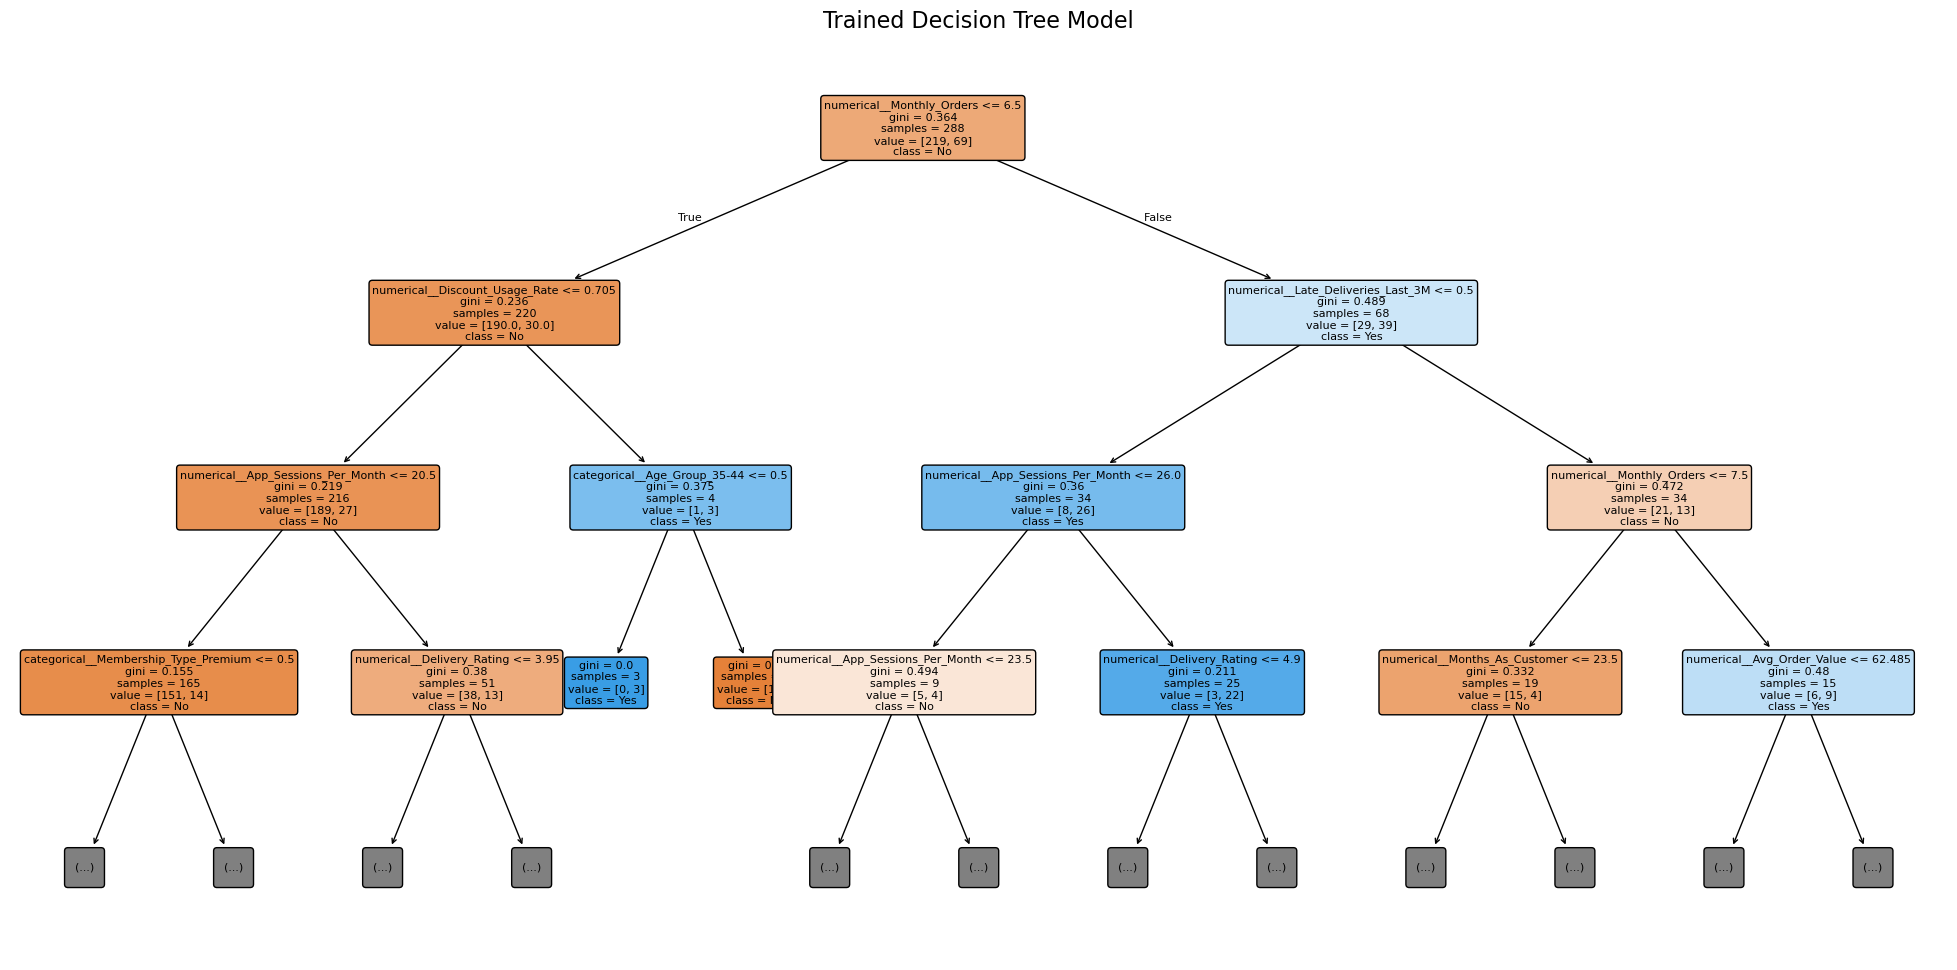

In [224]:
feature_names = dt_model.named_steps["preprocessor"].get_feature_names_out()

class_names = dt_model.named_steps["classifier"].classes_

plt.figure(figsize=(25, 12))

plot_tree(
    dt_model.named_steps["classifier"],
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)

plt.title("Trained Decision Tree Model", fontsize=16)
plt.show()

In [225]:
tree_depth = dt_model.named_steps["classifier"].get_depth()
tree_leaves = dt_model.named_steps["classifier"].get_n_leaves()

tree_complexity = pd.DataFrame({
    "Model": ["Decision Tree"],
    "Tree Depth": [tree_depth],
    "Number of Leaves": [tree_leaves]
})

tree_complexity

,Model,Tree Depth,Number of Leaves
0,Decision Tree,4,14


In [226]:
y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)

In [227]:
dt_train_accuracy = accuracy_score(y_train, y_train_pred)
dt_test_accuracy = accuracy_score(y_test, y_test_pred)

print("Decision Tree Training Accuracy:", dt_train_accuracy)
print("Decision Tree Testing Accuracy:", dt_test_accuracy)

Decision Tree Training Accuracy: 0.875
Decision Tree Testing Accuracy: 0.8333333333333334


In [228]:
dt_cm = confusion_matrix(y_test, y_test_pred, labels=["No", "Yes"])

print("Decision Tree Confusion Matrix:")
print(dt_cm)

Decision Tree Confusion Matrix:
[[54  1]
 [11  6]]


In [229]:
dt_cm_table = pd.DataFrame(
    dt_cm,
    index=["Actual No", "Actual Yes"],
    columns=["Predicted No", "Predicted Yes"]
)

dt_cm_table

,Predicted No,Predicted Yes
Actual No,54,1
Actual Yes,11,6


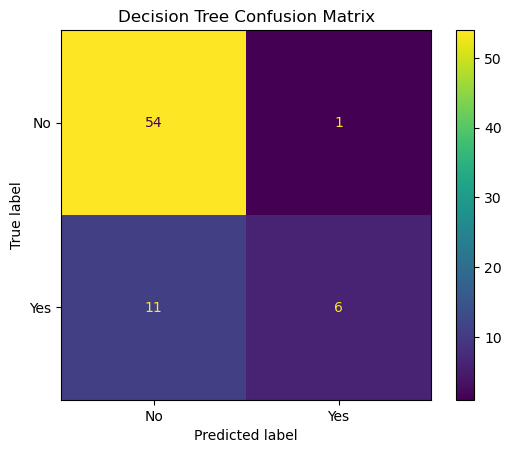

In [230]:
from sklearn.metrics import ConfusionMatrixDisplay

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=dt_cm,
    display_labels=["No", "Yes"]
)

cm_display.plot()

plt.title("Decision Tree Confusion Matrix")
plt.show()

In [231]:
dt_accuracy = accuracy_score(y_test, y_test_pred)
dt_precision = precision_score(y_test, y_test_pred, pos_label="Yes")
dt_recall = recall_score(y_test, y_test_pred, pos_label="Yes")
dt_f1 = f1_score(y_test, y_test_pred, pos_label="Yes")

print("Decision Tree Model Evaluation")
print("Accuracy:", dt_accuracy)
print("Precision:", dt_precision)
print("Recall:", dt_recall)
print("F1-score:", dt_f1)

Decision Tree Model Evaluation
Accuracy: 0.8333333333333334
Precision: 0.8571428571428571
Recall: 0.35294117647058826
F1-score: 0.5


In [232]:
print("Classification Report:")
print(classification_report(y_test, y_test_pred))

Classification Report:
              precision    recall  f1-score   support

          No       0.83      0.98      0.90        55
         Yes       0.86      0.35      0.50        17

    accuracy                           0.83        72
   macro avg       0.84      0.67      0.70        72
weighted avg       0.84      0.83      0.81        72



In [233]:
overfitting_gap = dt_train_accuracy - dt_test_accuracy

print("Overfitting Gap:", overfitting_gap)
print("Overfitting Explanation")

if overfitting_gap > 0.10:
    print("The Decision Tree model may be overfitting because the training accuracy is much higher than the testing accuracy.")
    print("This means the model may be learning the training data too closely and may not perform as well on new customer data.")
else:
    print("The Decision Tree model does not show a strong sign of overfitting.")
    print("The training accuracy and testing accuracy are reasonably close.")

Overfitting Gap: 0.04166666666666663
Overfitting Explanation
The Decision Tree model does not show a strong sign of overfitting.
The training accuracy and testing accuracy are reasonably close.


In [234]:
feature_names = dt_model.named_steps["preprocessor"].get_feature_names_out()

importance_values = dt_model.named_steps["classifier"].feature_importances_

dt_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

dt_feature_importance = dt_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

dt_feature_importance.head(10)

,Feature,Importance
20,numerical__Monthly_Orders,0.429340
26,numerical__Delivery_Rating,0.126186
25,numerical__App_Sessions_Per_Month,0.125400
22,numerical__Late_Deliveries_Last_3M,0.095281
24,numerical__Discount_Usage_Rate,0.058814
19,numerical__Months_As_Customer,0.053412
21,numerical__Avg_Order_Value,0.049702
10,categorical__Membership_Type_Premium,0.033111
2,categorical__Age_Group_35-44,0.028753
0,categorical__Age_Group_18-24,0.000000


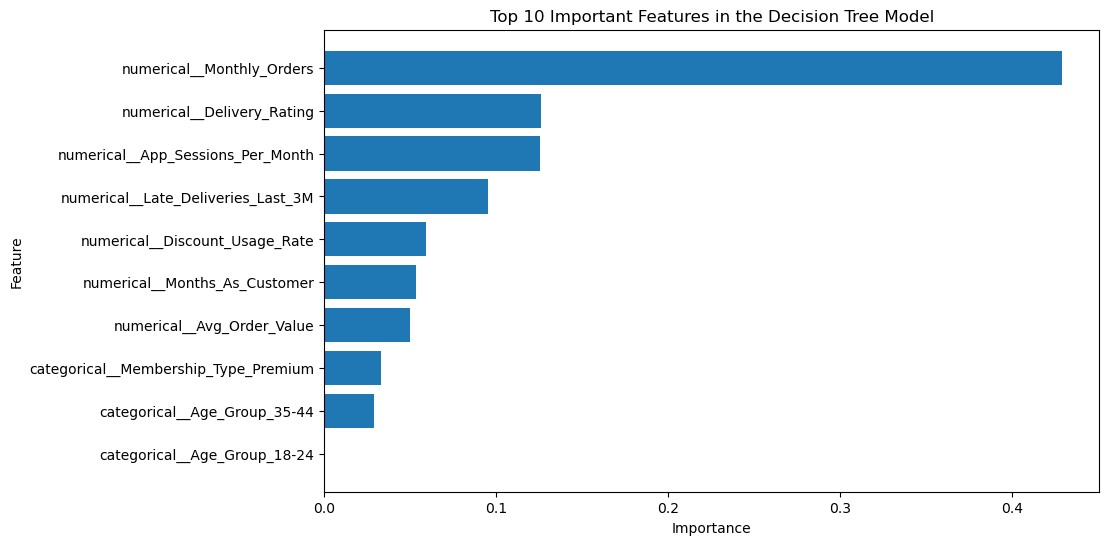

In [235]:
top_10_features = dt_feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_10_features["Feature"], top_10_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features in the Decision Tree Model")
plt.gca().invert_yaxis()
plt.show()

In [236]:
most_important_feature = dt_feature_importance.iloc[0]["Feature"]
most_important_value = dt_feature_importance.iloc[0]["Importance"]

print("Most Important Feature:", most_important_feature)
print("Importance Value:", most_important_value)

Most Important Feature: numerical__Monthly_Orders
Importance Value: 0.4293400957357772


## Task 4: Business Interpretation of Model Results

In [237]:
model_summary = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Testing Accuracy",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Decision Tree Result": [
        dt_train_accuracy,
        dt_test_accuracy,
        dt_accuracy,
        dt_precision,
        dt_recall,
        dt_f1
    ]
})

model_summary

,Metric,Decision Tree Result
0,Training Accuracy,0.875000
1,Testing Accuracy,0.833333
2,Accuracy,0.833333
3,Precision,0.857143
4,Recall,0.352941
5,F1-score,0.500000


In [238]:
dt_feature_importance.head(5)

,Feature,Importance
20,numerical__Monthly_Orders,0.429340
26,numerical__Delivery_Rating,0.126186
25,numerical__App_Sessions_Per_Month,0.125400
22,numerical__Late_Deliveries_Last_3M,0.095281
24,numerical__Discount_Usage_Rate,0.058814


**Write a short interpretation based on your model results and the business plan.**

**How well did the Decision Tree model perform?**

   The Decision Tree model performed well overall on the testing data. The testing accuracy was 0.8333, meaning the model correctly predicted about 83.33% of the customers in the testing data. The precision for Renewed_Membership = Yes was 0.8571, meaning that about 85.71% of the customers predicted to renew actually renewed. The recall was 0.3529, meaning the model correctly identified about 35.29% of the customers who truly renewed. The F1-score was 0.5000, which shows a moderate balance between precision and recall. Overall, the model gives FreshCart Plus a useful starting point, but the low recall for the Yes class means it still misses many customers who actually renew.

**Is there a large difference between training accuracy and testing accuracy?**

   No. The training accuracy was 0.8750, while the testing accuracy was 0.8333. This is a difference of about 0.0417, or 4.17 percentage points. This difference is small, so the model performs similarly on the training data and testing data.

**Does the model show signs of overfitting? Why or why not?**
 
   No. The model does not show strong signs of overfitting because the training accuracy and testing accuracy are reasonably close. The training accuracy was 87.50%, and the testing accuracy was 83.33%. Since the gap is only about 4.17 percentage points, the Decision Tree does not appear to be memorizing the training data too closely. It seems to generalize reasonably well to new FreshCart customer data.

**Which evaluation metric is most important for this business problem?**
  
   Recall for **Renewed_Membership = No** is especially important because FreshCart Plus wants to identify customers who may not renew before they leave. For the No-renewal class, the recall was 0.98, meaning the model identified most customers who actually did not renew. This is useful for FreshCart Plus because the business wants to find at-risk customers before they leave. If the model misses too many at-risk customers, the business may lose subscription revenue. However, precision for the No-renewal class is also important if FreshCart Plus has a limited retention budget and wants to avoid spending offers on customers who do not need them. F1-score is useful when the business wants a balance between precision and recall.

**What do false positives mean in this business context?**
   
   A false positive means the model predicted that a customer would renew, but the customer actually did not renew. In this model, there was 1 false positive. This is risky because FreshCart Plus may not contact that customer with retention support. As a result, the business may miss the chance to prevent churn and may lose subscription revenue.

**What do false negatives mean in this business context?**

   A false negative means the model predicted that a customer would not renew, but the customer actually renewed. In this model, there were 11 false negatives. This means FreshCart Plus may spend retention resources on customers who would have renewed anyway. This could lead to unnecessary discounts, unnecessary customer support follow-up, or inefficient use of the retention budget.

**Which features were most important in the Decision Tree model?**

   The most important features were shown in the feature importance table above. The top features with meaningful importance were Monthly_Orders, App_Sessions_Per_Month, Late_Deliveries_Last_3M, and Delivery_Rating. These were the variables the Decision Tree used most strongly when making renewal predictions. Other features, such as Discount_Usage_Rate, may still be useful for business understanding, but they were not as important in this specific Decision Tree model.

**How can these important features help the business make better decisions?**

   These important features can help FreshCart Plus understand which customer behaviours and service experiences are most connected to membership renewal. For example, Monthly_Orders can show how actively customers use the grocery service. App_Sessions_Per_Month` can show how engaged customers are with the app. Late_Deliveries_Last_3M and Delivery_Rating can help the business identify service quality problems that may affect renewal. 

**What is one possible limitation or bias in the model or dataset?**

   One limitation is that the dataset may not include all real-world reasons why customers renew or leave. Customer renewal may also depend on income, local grocery options, family schedule, product quality preferences, personal reasons, or competitor pricing. There may also be bias if some customer groups receive different delivery quality or different promotion exposure. Because of this, the model may not fully capture every factor that affects customer renewal.

**Why should human judgment still be used when making business decisions based on model results?**

   Human judgment should still be used because the model should support business decisions, not replace people. Even though the testing accuracy was strong at 83.33%, the model still made false positive and false negative errors. Managers should review model predictions carefully before deciding which customers should receive retention offers or customer support. This helps FreshCart Plus avoid unfair treatment and make more responsible customer retention decisions.

In [239]:
print("Final Conclusion")
print("This notebook used a Decision Tree classification model to predict FreshCart Plus membership renewal.")
print("The model achieved a testing accuracy of 0.8333.")
print("The model does not show a strong sign of overfitting because the training and testing accuracy scores are reasonably close.")
print("From a business perspective, the model can help FreshCart Plus identify customer renewal patterns and support retention decisions.")
print("The model should be used as a decision-support tool, not as the only basis for business decisions.")

Final Conclusion
This notebook used a Decision Tree classification model to predict FreshCart Plus membership renewal.
The model achieved a testing accuracy of 0.8333.
The model does not show a strong sign of overfitting because the training and testing accuracy scores are reasonably close.
From a business perspective, the model can help FreshCart Plus identify customer renewal patterns and support retention decisions.
The model should be used as a decision-support tool, not as the only basis for business decisions.


In [254]:
import os

output_folder = "outputs"
os.makedirs(output_folder, exist_ok=True)

print("Output folder is ready:", output_folder)

Output folder is ready: outputs


In [260]:
model_results = pd.DataFrame({
    "Model": ["Decision Tree"],
    "Training Accuracy": [dt_train_accuracy],
    "Testing Accuracy": [dt_test_accuracy],
    "Accuracy": [dt_accuracy],
    "Precision": [dt_precision],
    "Recall": [dt_recall],
    "F1-Score": [dt_f1],
    "Overfitting Gap": [dt_train_accuracy - dt_test_accuracy]
})

model_results

,Model,Training Accuracy,Testing Accuracy,Accuracy,Precision,Recall,F1-Score,Overfitting Gap
0,Decision Tree,0.875,0.833333,0.833333,0.857143,0.352941,0.5,0.041667


In [261]:
model_results.to_csv("outputs/decision_tree_model_results.csv", index=False)

print("Model results saved as: outputs/decision_tree_model_results.csv")

Model results saved as: outputs/decision_tree_model_results.csv


In [262]:
confusion_matrix_table = pd.DataFrame(
    dt_cm,
    index=["Actual No", "Actual Yes"],
    columns=["Predicted No", "Predicted Yes"]
)

confusion_matrix_table

,Predicted No,Predicted Yes
Actual No,54,1
Actual Yes,11,6


In [263]:
confusion_matrix_table.to_csv("outputs/decision_tree_confusion_matrix.csv")

print("Confusion matrix saved as: outputs/decision_tree_confusion_matrix.csv")

Confusion matrix saved as: outputs/decision_tree_confusion_matrix.csv


In [264]:
predictions_table = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_test_pred
})

predictions_table.head()

,Actual,Predicted
63,No,No
359,No,No
24,No,No
324,Yes,No
17,No,No


In [265]:
predictions_table.to_csv("outputs/decision_tree_predictions.csv", index=False)

print("Predictions saved as: outputs/decision_tree_predictions.csv")

Predictions saved as: outputs/decision_tree_predictions.csv


In [266]:
df_clean.to_csv("outputs/cleaned_freshcart_subscription_dataset.csv", index=False)

print("Cleaned dataset saved as: outputs/cleaned_freshcart_subscription_dataset.csv")

Cleaned dataset saved as: outputs/cleaned_freshcart_subscription_dataset.csv


In [267]:
dt_feature_importance.to_csv("outputs/decision_tree_feature_importance.csv", index=False)

print("Feature importance saved as: outputs/decision_tree_feature_importance.csv")

Feature importance saved as: outputs/decision_tree_feature_importance.csv


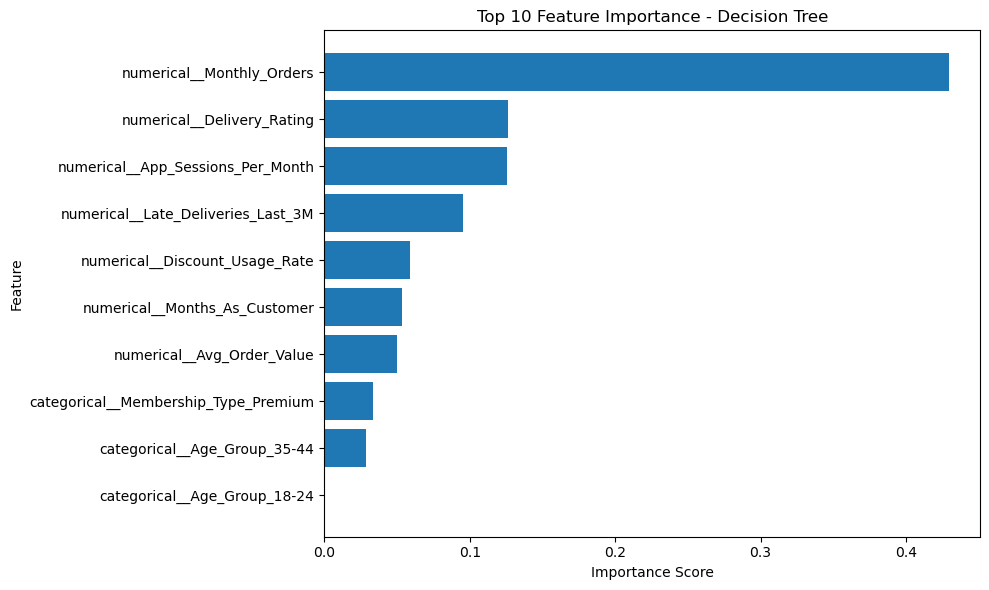

Chart saved as: outputs/decision_tree_feature_importance.png


In [268]:
top_features = dt_feature_importance.head(10)

top_features_plot = top_features.sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features_plot["Feature"],
    top_features_plot["Importance"]
)

plt.title("Top 10 Feature Importance - Decision Tree")

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.tight_layout()

plt.savefig("outputs/decision_tree_feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

print("Chart saved as: outputs/decision_tree_feature_importance.png")

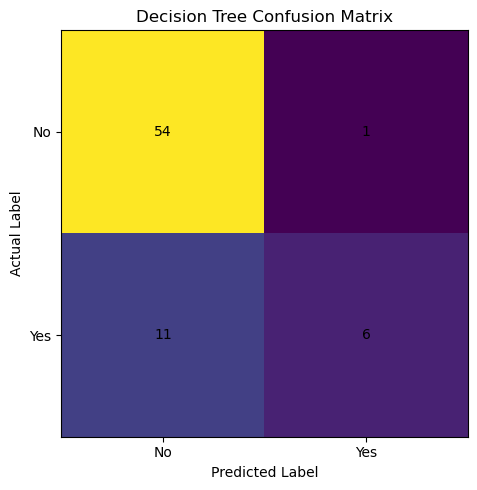

Chart saved as: outputs/decision_tree_confusion_matrix.png


In [269]:
plt.figure(figsize=(6, 5))

plt.imshow(dt_cm)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["No", "Yes"])
plt.yticks([0, 1], ["No", "Yes"])

for i in range(dt_cm.shape[0]):
    for j in range(dt_cm.shape[1]):
        plt.text(j, i, dt_cm[i, j], ha="center", va="center")

plt.tight_layout()

plt.savefig("outputs/decision_tree_confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

print("Chart saved as: outputs/decision_tree_confusion_matrix.png")

In [270]:
github_checklist = pd.DataFrame({

    "Submission Item": [
        "Completed Jupyter Notebook",
        "Dataset file, if allowed",
        "Cleaned dataset output",
        "Model summary output",
        "Feature importance output",
        "Decision Tree visualization",
        "README file",
        "Business interpretation",
        "All notebook cells run without errors",
        "GitHub repository link submitted on Canvas"
    ],

    "Status": [
        "Required",
        "Required if allowed",
        "Recommended",
        "Recommended",
        "Recommended",
        "Recommended",
        "Required",
        "Required",
        "Required",
        "Required"
    ]
})

display(github_checklist)

,Submission Item,Status
0,Completed Jupyter Notebook,Required
1,"Dataset file, if allowed",Required if allowed
2,Cleaned dataset output,Recommended
3,Model summary output,Recommended
4,Feature importance output,Recommended
5,Decision Tree visualization,Recommended
6,README file,Required
7,Business interpretation,Required
8,All notebook cells run without errors,Required
9,GitHub repository link submitted on Canvas,Required
